In [42]:
import uproot
import pandas as pd
import numpy as np
import awkward as ak
import os
import json
import ROOT

In [43]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
import matplotlib.lines as lines
from matplotlib.collections import PatchCollection
plt.rcParams.update({'font.size': 15})

In [44]:
basedir = os.path.join(os.environ.get('ttH_yy_DIR'), 'final')
outdir = os.path.join(os.environ.get('ttH_yy_DIR'), 'plots')
process = {
    'ttHyy' : { 'sample_list' : ['mgp8_pp_tth01j_5f_haa'], 
               'label' : r'$ttH \rightarrow \gamma\gamma$'},
    'ttyy' : { 'sample_list' : ['mgp8_pp_ttaa_semilep_5f_100TeV'], 
               'label' : '$tt\gamma\gamma$'}
}

selection = {
    'sel0_nocuts' : "All events"
}

process_infos = "/eos/experiment/fcc/hh/utils/FCCDicts/FCChh_procDict_fcc_v06_II.json"

lumi = 3e7 # 3 * 10^7 pb-1 = 3 ab-1

In [65]:
with open(process_infos, 'r') as f :
    process_dict = json.load(f)

In [66]:
rdf = {}
sow = {}

In [67]:
for p in process.keys() :
    rdf[p] = {}
    for s in selection.keys() :
        rdf[p][s] = {}
        sow[p] = {}
        for sample in process[p]['sample_list'] : 
            inputfile = os.path.join(basedir, sample+"_"+s+".root")
            # get sum of weights
            f = ROOT.TFile.Open(inputfile)
            sow[p][sample] = f.Get("SumOfWeights").GetVal()
            f.Close()
            # get sample
            rdf[p][s][sample] = ROOT.RDataFrame("events", inputfile)
            weight = "weight/{sow}*{xs}*{k}*{eff}".format(
                sow=sow[p][sample],
                xs = process_dict[sample]['crossSection'],
                k = process_dict[sample]['kfactor'],
                eff = process_dict[sample]['matchingEfficiency']
            )
            rdf[p][s][sample] = rdf[p][s][sample].Redefine("weight", weight)

In [68]:
for p in process.keys() :
    for s in selection.keys() :
        for sample in process[p]['sample_list'] : 
            rdf[p][s][sample] = rdf[p][s][sample].Define("pT_jet5", "n_jets >= 5 ? pT_jets[4] : -999.")
            rdf[p][s][sample] = rdf[p][s][sample].Define("pT_jet6", "n_jets >= 6 ? pT_jets[5] : -999.")

In [69]:
histo = {}

In [70]:
for p in process.keys() :
    histo[p] = {}
    for s in selection.keys() :
        histo[p][s] = {}
        model = ROOT.RDF.TH1DModel("", "", 50, 0., 200.) 
        histo[p][s] = rdf[p][s][process[p]['sample_list'][0]].Histo1D(model, "pT_jet5", "weight")
        for sample in process[p]['sample_list'][1:] :
            temp = rdf[p][s][sample].Histo1D(model, "pT_jet5", "weight")
            histo[p][s].Add(temp)

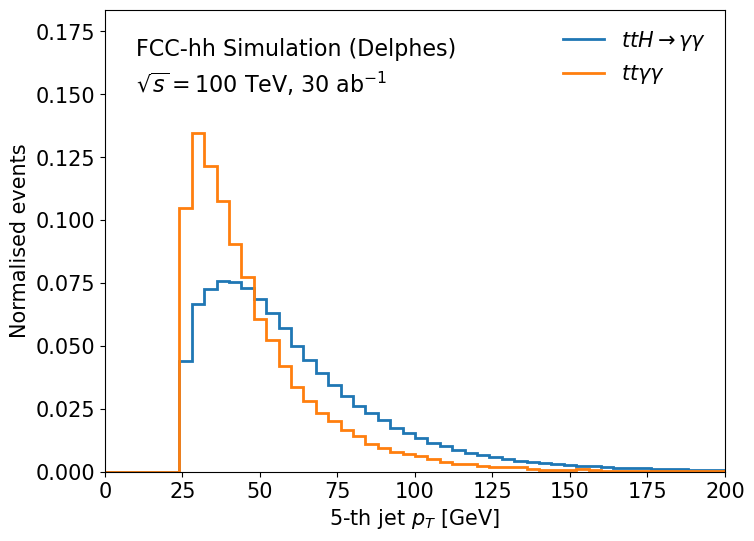

In [71]:
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

sel_key = list(selection.keys())[0]
sel_label = list(selection.keys())[0]

for p in process.keys() :
    nbins = histo[p][sel_key].GetXaxis().GetNbins()
    bin_edges  = [histo[p][sel_key].GetXaxis().GetBinLowEdge(i+1) for i in range(0, nbins+1)]
    bin_values = [histo[p][sel_key].GetBinContent(i+1) for i in range(0, nbins)]
    bin_errors = [histo[p][sel_key].GetBinError(i+1) for i in range(0, nbins)]
    norm = np.sum(np.array(bin_values))
    ax.stairs(bin_values/norm, bin_edges, fill=False, linestyle='-', linewidth=2, label=process[p]["label"])

#ax.text(0.05, 0.90, r"$ttH \rightarrow \gamma\gamma$", transform=ax.transAxes, fontsize=18)
ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)

ax.text(0.05, 0.82, r"$\sqrt{s}=100$ TeV, 30 ab$^{-1}$", transform=ax.transAxes, fontsize=16)

ax.legend(loc='upper right', frameon=False, fontsize=15)

ax.set_xlabel(r'5-th jet $p_{T}$ [GeV]')    
ax.set_ylabel(r'Normalised events')

ax.set_xlim(bin_edges[0], bin_edges[-1])
ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.3)

plotname = os.path.join(outdir, "pT_jet5_ttH_yy_analysis.pdf")
plt.savefig(plotname, bbox_inches='tight')
plotname = os.path.join(outdir, "pT_jet5_ttH_yy_analysis.png")
plt.savefig(plotname, bbox_inches='tight')
plt.show()

In [72]:
histo = {}

In [73]:
for p in process.keys() :
    histo[p] = {}
    for s in selection.keys() :
        histo[p][s] = {}
        model = ROOT.RDF.TH1DModel("", "", 50, 0., 200.) 
        histo[p][s] = rdf[p][s][process[p]['sample_list'][0]].Histo1D(model, "pT_jet6", "weight")
        for sample in process[p]['sample_list'][1:] :
            temp = rdf[p][s][sample].Histo1D(model, "pT_jet6", "weight")
            histo[p][s].Add(temp)

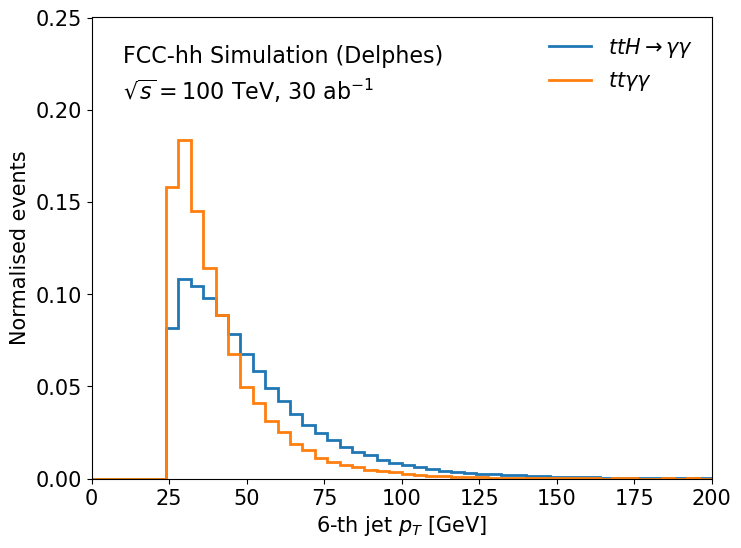

In [74]:
fig, ax = plt.subplots(
    nrows=1,
    ncols=1,
    figsize=(8,6)
)

sel_key = list(selection.keys())[0]
sel_label = list(selection.keys())[0]

for p in process.keys() :
    nbins = histo[p][sel_key].GetXaxis().GetNbins()
    bin_edges  = [histo[p][sel_key].GetXaxis().GetBinLowEdge(i+1) for i in range(0, nbins+1)]
    bin_values = [histo[p][sel_key].GetBinContent(i+1) for i in range(0, nbins)]
    bin_errors = [histo[p][sel_key].GetBinError(i+1) for i in range(0, nbins)]
    norm = np.sum(np.array(bin_values))
    ax.stairs(bin_values/norm, bin_edges, fill=False, linestyle='-', linewidth=2, label=process[p]["label"])

#ax.text(0.05, 0.90, r"$ttH \rightarrow \gamma\gamma$", transform=ax.transAxes, fontsize=18)
ax.text(0.05, 0.90, r"FCC-hh Simulation (Delphes)", transform=ax.transAxes, fontsize=16)

ax.text(0.05, 0.82, r"$\sqrt{s}=100$ TeV, 30 ab$^{-1}$", transform=ax.transAxes, fontsize=16)

ax.legend(loc='upper right', frameon=False, fontsize=15)

ax.set_xlabel(r'6-th jet $p_{T}$ [GeV]')    
ax.set_ylabel(r'Normalised events')

ax.set_xlim(bin_edges[0], bin_edges[-1])
ymin,ymax = ax.get_ylim() 
ax.set_ylim(ymin, ymax+np.abs((ymax-ymin))*0.3)

plotname = os.path.join(outdir, "pT_jet6_ttH_yy_analysis.pdf")
plt.savefig(plotname, bbox_inches='tight')
plotname = os.path.join(outdir, "pT_jet6_ttH_yy_analysis.png")
plt.savefig(plotname, bbox_inches='tight')
plt.show()